# Individual F0 Reliance Analysis

This notebook analyzes individual subject's reliance on F0 vs VOT cues in perception.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Load Data

In [2]:
# Load individual coefficients
coefficients_df = pd.read_csv('../shared/output/individual_mclogit_coefficients.csv')

# Load perception data to get age information
perception_df = pd.read_csv('../shared/output/perception_preprocessed_data.csv')

print(f"Coefficients data shape: {coefficients_df.shape}")
print(f"Perception data shape: {perception_df.shape}")
coefficients_df.head()

Coefficients data shape: (540, 6)
Perception data shape: (31059, 35)


,subject,term,Estimate,Std. Error,z value,Pr(>|z|)
0,311,asp~(Intercept),0.234938,0.420965,0.558094,5.767804e-01
1,311,fortis~(Intercept),-0.271331,0.463898,-0.584893,5.586196e-01
2,311,asp~svot,3.752087,0.439557,8.536066,1.388689e-17
3,311,fortis~svot,-2.673539,0.429511,-6.224615,4.827415e-10
4,311,asp~sf0,4.440235,0.436105,10.181575,2.396508e-24


## Calculate F0 Reliance

F0 Reliance = |F0 coefficient| / (|F0 coefficient| + |VOT coefficient|)

In [3]:
# Extract F0 and VOT coefficients for each subject
# Calculate F0 reliance separately for aspirated and fortis contrasts

# For ASPIRATED contrast (asp~)
asp_f0_coef = coefficients_df[coefficients_df['term'] == 'asp~sf0'][['subject', 'Estimate']].copy()
asp_f0_coef.columns = ['subject', 'asp_f0_coef']

asp_vot_coef = coefficients_df[coefficients_df['term'] == 'asp~svot'][['subject', 'Estimate']].copy()
asp_vot_coef.columns = ['subject', 'asp_vot_coef']

# For FORTIS contrast (fortis~)
fortis_f0_coef = coefficients_df[coefficients_df['term'] == 'fortis~sf0'][['subject', 'Estimate']].copy()
fortis_f0_coef.columns = ['subject', 'fortis_f0_coef']

fortis_vot_coef = coefficients_df[coefficients_df['term'] == 'fortis~svot'][['subject', 'Estimate']].copy()
fortis_vot_coef.columns = ['subject', 'fortis_vot_coef']

# Merge all coefficients
reliance_df = asp_f0_coef.merge(asp_vot_coef, on='subject')
reliance_df = reliance_df.merge(fortis_f0_coef, on='subject')
reliance_df = reliance_df.merge(fortis_vot_coef, on='subject')

# Calculate F0 reliance for both contrasts
reliance_df['asp_f0_reliance'] = np.abs(reliance_df['asp_f0_coef']) / (np.abs(reliance_df['asp_f0_coef']) + np.abs(reliance_df['asp_vot_coef']))
reliance_df['fortis_f0_reliance'] = np.abs(reliance_df['fortis_f0_coef']) / (np.abs(reliance_df['fortis_f0_coef']) + np.abs(reliance_df['fortis_vot_coef']))

print(f"Number of subjects: {len(reliance_df)}")
reliance_df.head()

Number of subjects: 54


,subject,asp_f0_coef,asp_vot_coef,fortis_f0_coef,fortis_vot_coef,asp_f0_reliance,fortis_f0_reliance
0,311,4.440235,3.752087,4.122219,-2.673539,0.542000,0.606587
1,619,2.376933,0.789877,1.913518,-3.615684,0.750576,0.346075
2,312,4.813297,2.102028,3.406414,-4.762115,0.696033,0.417017
3,304,3.066639,2.452732,2.969134,-3.737329,0.555614,0.442727
4,609,3.032924,2.997842,2.120147,-2.886635,0.502909,0.423455


## Add Age Information and Calculate Year of Birth

In [4]:
# Get unique age for each subject
age_df = perception_df[['subject', 'age']].drop_duplicates()

# Convert subject to string in both dataframes to ensure proper merge
reliance_df['subject'] = reliance_df['subject'].astype(str)
age_df['subject'] = age_df['subject'].astype(str)

# Merge with reliance data
reliance_df = reliance_df.merge(age_df, on='subject', how='left')

# Calculate year of birth (based on 2024)
reliance_df['yob'] = 2024 - reliance_df['age']

# Sort by year of birth (ascending)
reliance_df = reliance_df.sort_values('yob')

print(f"Year of birth range: {reliance_df['yob'].min()} - {reliance_df['yob'].max()}")
reliance_df

Year of birth range: 1952 - 2004


,subject,asp_f0_coef,asp_vot_coef,fortis_f0_coef,fortis_vot_coef,asp_f0_reliance,fortis_f0_reliance,age,yob
12,703,4.772865,4.119163,2.083510,-4.599850,0.536758,0.311746,72,1952
23,701,6.939740,0.960482,6.426231,-5.085869,0.878423,0.558215,69,1955
28,618,2.865413,1.807283,2.239867,-4.023250,0.613225,0.357628,68,1956
46,605,2.840605,2.813040,1.567388,-2.690856,0.502438,0.368083,67,1957
36,604,4.537549,3.161529,3.568764,-3.671132,0.589363,0.492930,66,1958
1,619,2.376933,0.789877,1.913518,-3.615684,0.750576,0.346075,65,1959
15,601,3.946412,4.292479,2.496840,-2.794533,0.478998,0.471870,64,1960
4,609,3.032924,2.997842,2.120147,-2.886635,0.502909,0.423455,64,1960
48,614,3.300199,4.087363,0.987003,-6.200110,0.446724,0.137330,64,1960
39,608,3.437190,4.261867,2.621469,-3.340799,0.446443,0.439676,64,1960


## Plot F0 Reliance by Year of Birth

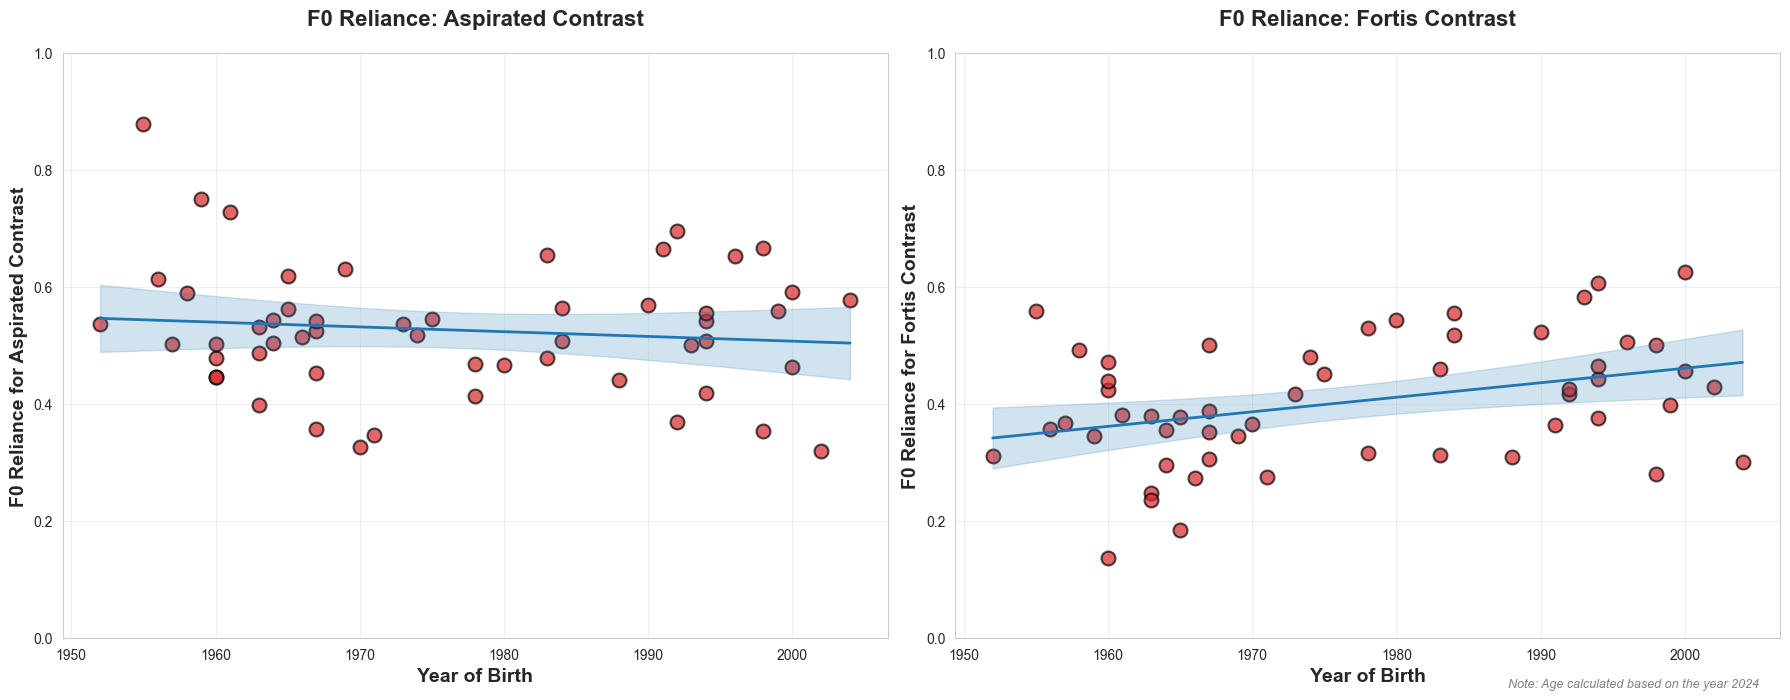


=== ASPIRATED Contrast ===
Mean F0 Reliance: 0.526
Median F0 Reliance: 0.521
Std Dev F0 Reliance: 0.109

=== FORTIS Contrast ===
Mean F0 Reliance: 0.403
Median F0 Reliance: 0.393
Std Dev F0 Reliance: 0.106


In [5]:
from scipy import stats

def calculate_regression_confidence_band(x, y, confidence=0.95):
    """
    Calculate confidence band for linear regression (like R's geom_smooth)
    Returns prediction and confidence intervals that vary with x
    """
    n = len(x)
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    
    # Predictions
    y_pred = slope * x + intercept
    
    # Residuals and MSE
    residuals = y - y_pred
    mse = np.sum(residuals**2) / (n - 2)
    
    # Standard error of predictions (varies with x)
    x_mean = np.mean(x)
    x_var = np.sum((x - x_mean)**2)
    
    # Standard error for each x point
    se = np.sqrt(mse * (1/n + (x - x_mean)**2 / x_var))
    
    # t-value for confidence interval
    t_val = stats.t.ppf((1 + confidence) / 2, n - 2)
    
    # Confidence intervals
    ci_lower = y_pred - t_val * se
    ci_upper = y_pred + t_val * se
    
    return y_pred, ci_lower, ci_upper, slope, intercept, r_value, p_value

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Prepare data
x = reliance_df['yob'].values
y_asp = reliance_df['asp_f0_reliance'].values
y_fortis = reliance_df['fortis_f0_reliance'].values

# Sort by x for smooth plotting
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
y_asp_sorted = y_asp[sort_idx]
y_fortis_sorted = y_fortis[sort_idx]

# Plot for ASPIRATED contrast
ax1 = axes[0]
ax1.scatter(x, y_asp, s=100, alpha=0.7, edgecolors='black', linewidth=1.5, 
           color='#d62728')

# Calculate and plot regression with confidence band
pred_asp, ci_lower_asp, ci_upper_asp, slope_asp, intercept_asp, r_asp, p_asp = \
    calculate_regression_confidence_band(x_sorted, y_asp_sorted)

ax1.plot(x_sorted, pred_asp, color='#1f77b4', linewidth=2)
ax1.fill_between(x_sorted, ci_lower_asp, ci_upper_asp, 
                alpha=0.2, color='#1f77b4')

ax1.set_xlabel('Year of Birth', fontsize=14, fontweight='bold')
ax1.set_ylabel('F0 Reliance for Aspirated Contrast', fontsize=14, fontweight='bold')
ax1.set_title('F0 Reliance: Aspirated Contrast', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylim(0, 1)
ax1.set_yticks(np.arange(0, 1.1, 0.2))
ax1.grid(True, alpha=0.3)

# Plot for FORTIS contrast
ax2 = axes[1]
ax2.scatter(x, y_fortis, s=100, alpha=0.7, edgecolors='black', linewidth=1.5, 
           color='#d62728')

# Calculate and plot regression with confidence band
pred_fortis, ci_lower_fortis, ci_upper_fortis, slope_fortis, intercept_fortis, r_fortis, p_fortis = \
    calculate_regression_confidence_band(x_sorted, y_fortis_sorted)

ax2.plot(x_sorted, pred_fortis, color='#1f77b4', linewidth=2)
ax2.fill_between(x_sorted, ci_lower_fortis, ci_upper_fortis, 
                alpha=0.2, color='#1f77b4')

ax2.set_xlabel('Year of Birth', fontsize=14, fontweight='bold')
ax2.set_ylabel('F0 Reliance for Fortis Contrast', fontsize=14, fontweight='bold')
ax2.set_title('F0 Reliance: Fortis Contrast', fontsize=16, fontweight='bold', pad=20)
ax2.set_ylim(0, 1)
ax2.set_yticks(np.arange(0, 1.1, 0.2))
ax2.grid(True, alpha=0.3)

# Add footnote (right-aligned, lower position, gray color)
fig.text(0.98, 0.01, 'Note: Age calculated based on the year 2024', 
         ha='right', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)  # Add space at bottom for note
plt.show()

# Print summary statistics
print("\n=== ASPIRATED Contrast ===")
print(f"Mean F0 Reliance: {y_asp.mean():.3f}")
print(f"Median F0 Reliance: {np.median(y_asp):.3f}")
print(f"Std Dev F0 Reliance: {y_asp.std():.3f}")

print("\n=== FORTIS Contrast ===")
print(f"Mean F0 Reliance: {y_fortis.mean():.3f}")
print(f"Median F0 Reliance: {np.median(y_fortis):.3f}")
print(f"Std Dev F0 Reliance: {y_fortis.std():.3f}")

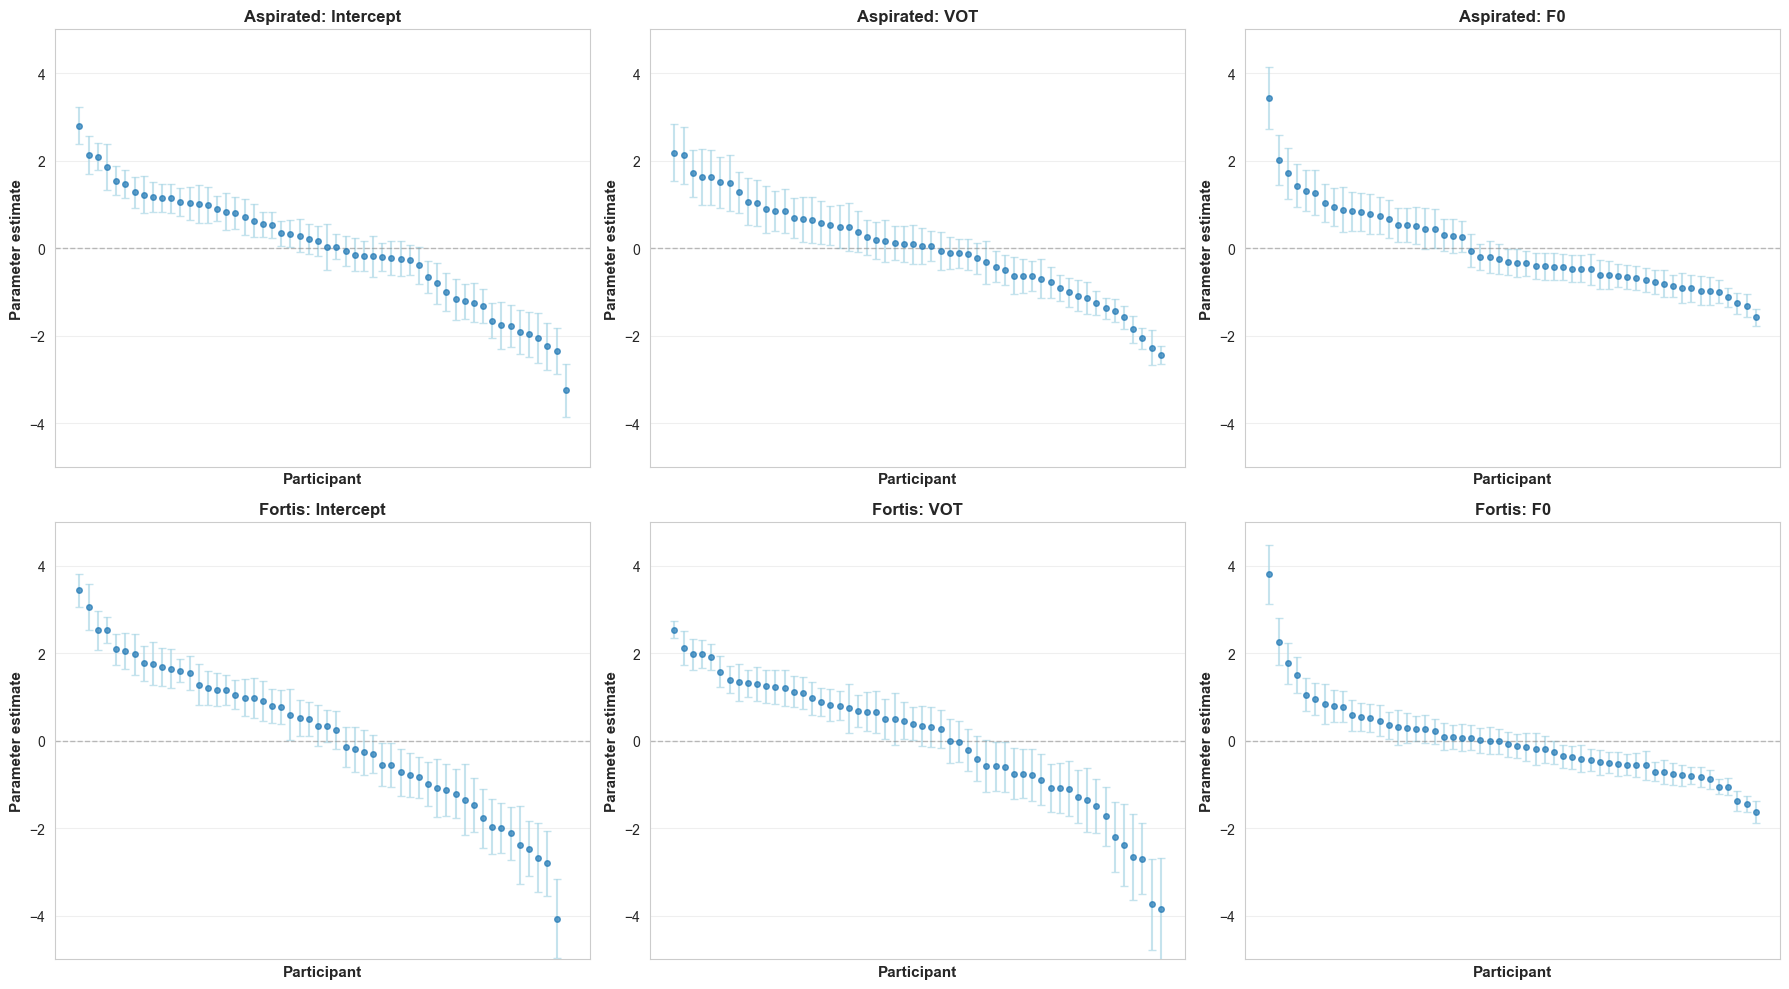

In [6]:
# TODO: 이전 그래프와 좀 다른데 확인 필요
# Individual Coefficient Estimates by Participant
# Create 2x3 grid for coefficient estimates (Aspirated vs Fortis × Intercept/VOT/F0)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Define the terms to plot
contrasts = ['asp', 'fortis']
predictors = [('(Intercept)', 'Intercept'), ('svot', 'VOT'), ('sf0', 'F0')]

for row_idx, contrast in enumerate(contrasts):
    for col_idx, (pred_term, pred_label) in enumerate(predictors):
        ax = axes[row_idx, col_idx]
        
        # Filter data for this contrast and predictor
        if pred_term == '(Intercept)':
            term_filter = f'{contrast}~{pred_term}'
        else:
            term_filter = f'{contrast}~{pred_term}'
        
        plot_data = coefficients_df[coefficients_df['term'] == term_filter].copy()
        
        # Center by mean
        mean_estimate = plot_data['Estimate'].mean()
        plot_data['Estimate_centered'] = plot_data['Estimate'] - mean_estimate
        
        # Sort by centered estimate (descending)
        plot_data = plot_data.sort_values('Estimate_centered', ascending=False).reset_index(drop=True)
        
        # Create x positions (just sequential)
        x_pos = np.arange(len(plot_data))
        
        # Plot with error bars
        ax.errorbar(x_pos, plot_data['Estimate_centered'], 
                   yerr=plot_data['Std. Error'],
                   fmt='o', markersize=4, capsize=3, capthick=1,
                   color='#1f77b4', ecolor='lightblue', alpha=0.7)
        
        # Add horizontal line at y=0 (the mean)
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
        
        # Set labels and title
        ax.set_xlabel('Participant', fontsize=11, fontweight='bold')
        ax.set_ylabel('Parameter estimate', fontsize=11, fontweight='bold')
        
        # Title formatting
        contrast_label = 'Aspirated' if contrast == 'asp' else 'Fortis'
        ax.set_title(f'{contrast_label}: {pred_label}', fontsize=12, fontweight='bold')
        
        # Set y limits
        ax.set_ylim(-5, 5)
        
        # Remove x ticks but keep the label
        ax.set_xticks([])
        
        # Grid
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Individual LDA Heatmap Analysis

**Note**: LDA heatmap analysis is now performed in `../shared/individual_lda_modeling.ipynb`.

The heatmap generation has been moved to avoid redundant model fitting. 
See `../shared/individual_lda_modeling.ipynb` for:
- Individual LDA model fitting
- Coefficient extraction
- Heatmap visualization

Output saved to: `../shared/output/individual_lda_heatmaps/all_participants_lda_heatmaps.png`

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to create individual participant LDA grid heatmap
def create_participant_lda_heatmap(participant_id, prolific_id, participant_data, lda_model, ax, grid_size=10):
    """
    Create LDA grid heatmap for a single participant
    
    Parameters:
    - participant_id: participant ID
    - prolific_id: prolific participant ID
    - participant_data: DataFrame with participant's data
    - lda_model: fitted LDA model
    - ax: matplotlib axis to plot on
    - grid_size: number of cells in each dimension
    """
    
    # Prepare data
    X_participant_df = participant_data[['svot', 'sf0']].dropna()
    X_participant = X_participant_df.values
    y_participant = participant_data.loc[X_participant_df.index, 'response'].values
    
    # Create display ID (special handling for prolific_id 603)
    if str(prolific_id) == '603':
        if participant_id == 464:
            display_id = "603-467"
        elif participant_id == 465:
            display_id = "603-469"
        elif participant_id == 469:
            display_id = "603-465"
        elif participant_id == 467:
            display_id = "603-464"
        else:
            display_id = f"{prolific_id}-{participant_id}"
    else:
        display_id = str(prolific_id)
    
    # Model accuracy
    y_pred = lda_model.predict(X_participant)
    accuracy = (y_pred == y_participant).mean()
    
    # Grid setup
    x_min, x_max = X_participant_df['svot'].min() - 1, X_participant_df['svot'].max() + 1
    y_min, y_max = X_participant_df['sf0'].min() - 1, X_participant_df['sf0'].max() + 1
    
    x_bins = np.linspace(x_min, x_max, grid_size + 1)
    y_bins = np.linspace(y_min, y_max, grid_size + 1)
    
    x_centers = (x_bins[:-1] + x_bins[1:]) / 2
    y_centers = (y_bins[:-1] + y_bins[1:]) / 2
    
    # Calculate actual data proportions in each grid cell
    class_abbrev = {'asp': 'A', 'lenis': 'L', 'fortis': 'F'}
    class_to_idx = {class_name: idx for idx, class_name in enumerate(lda_model.classes_)}
    
    # Initialize grid
    actual_counts = np.zeros((grid_size, grid_size, len(lda_model.classes_)))
    total_counts = np.zeros((grid_size, grid_size))
    
    # Assign each data point to a grid cell
    for enum_idx, idx in enumerate(X_participant_df.index):
        x_val = X_participant_df.loc[idx, 'svot']
        y_val = X_participant_df.loc[idx, 'sf0']
        class_name = y_participant[enum_idx]
        
        x_bin = np.digitize(x_val, x_bins) - 1
        y_bin = np.digitize(y_val, y_bins) - 1
        
        x_bin = np.clip(x_bin, 0, grid_size - 1)
        y_bin = np.clip(y_bin, 0, grid_size - 1)
        
        class_idx = list(lda_model.classes_).index(class_name)
        actual_counts[y_bin, x_bin, class_idx] += 1
        total_counts[y_bin, x_bin] += 1
    
    # Calculate proportions
    proportions = np.zeros_like(actual_counts)
    for i in range(grid_size):
        for j in range(grid_size):
            if total_counts[i, j] > 0:
                proportions[i, j, :] = actual_counts[i, j, :] / total_counts[i, j]
    
    # Create color matrix
    color_matrix = np.ones((grid_size, grid_size, 3))
    asp_idx = class_to_idx.get('asp', 0)
    lenis_idx = class_to_idx.get('lenis', 1)
    fortis_idx = class_to_idx.get('fortis', 2)
    
    for i in range(grid_size):
        for j in range(grid_size):
            if total_counts[i, j] == 0:
                continue
                
            asp_prop = proportions[i, j, asp_idx]
            lenis_prop = proportions[i, j, lenis_idx]
            fortis_prop = proportions[i, j, fortis_idx]
            
            # Color mixing: lenis #1f77b4, fortis #ff7f0e, asp #2ca02c
            color_matrix[i, j, 0] = lenis_prop * 0.122 + fortis_prop * 1.0 + asp_prop * 0.173
            color_matrix[i, j, 1] = lenis_prop * 0.467 + fortis_prop * 0.498 + asp_prop * 0.627
            color_matrix[i, j, 2] = lenis_prop * 0.706 + fortis_prop * 0.055 + asp_prop * 0.173
    
    color_matrix = np.clip(color_matrix, 0, 1)
    
    # Plot
    ax.imshow(color_matrix, extent=[x_min, x_max, y_min, y_max], 
              origin='lower', aspect='auto', interpolation='nearest', vmin=0, vmax=1)
    
    # Add text annotations
    for i in range(grid_size):
        for j in range(grid_size):
            if total_counts[i, j] == 0:
                continue
            
            cell_counts = actual_counts[i, j, :]
            max_count = cell_counts.max()
            
            top_classes = []
            for class_idx, class_name in enumerate(lda_model.classes_):
                if cell_counts[class_idx] == max_count:
                    abbrev = class_abbrev.get(class_name, class_name[0].upper())
                    top_classes.append(abbrev)
            
            top_classes.sort()
            top_prop = max_count / total_counts[i, j] * 100
            
            if len(top_classes) == 1:
                text = f"{top_classes[0]} {top_prop:.1f}"
            else:
                text = f"{''.join(top_classes)} {top_prop:.0f}"
            
            x_pos = x_centers[j]
            y_pos = y_centers[i]
            
            brightness = np.mean(color_matrix[i, j])
            text_color = 'black' if brightness > 0.6 else 'white'
            
            ax.text(x_pos, y_pos, text, ha='center', va='center',
                    fontsize=6, fontweight='bold', color=text_color)
    
    # Decision boundaries
    try:
        xx_fine, yy_fine = np.meshgrid(np.linspace(x_min, x_max, 500), 
                                       np.linspace(y_min, y_max, 500))
        Z_boundary = lda_model.predict(np.c_[xx_fine.ravel(), yy_fine.ravel()])
        Z_boundary_encoded = np.array([list(lda_model.classes_).index(z) for z in Z_boundary]).reshape(xx_fine.shape)
        ax.contour(xx_fine, yy_fine, Z_boundary_encoded, colors='black', linewidths=1.0, levels=2, alpha=0.5)
    except:
        pass
    
    # Grid lines
    for x_line in x_bins:
        ax.axvline(x_line, color='gray', linewidth=0.3, alpha=0.4)
    for y_line in y_bins:
        ax.axhline(y_line, color='gray', linewidth=0.3, alpha=0.4)
    
    # Get participant age and gender
    participant_age = participant_data['age'].iloc[0]
    participant_gender = participant_data['gender'].iloc[0]
    
    # Labels and title
    ax.set_xlabel('VOT', fontsize=8)
    ax.set_ylabel('F0', fontsize=8)
    ax.set_title(f'P{display_id} ({participant_age}, {participant_gender}) - Acc: {accuracy*100:.1f}%', 
                 fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    
    return accuracy

print("Heatmap function defined successfully.")

Heatmap function defined successfully.


In [8]:
# Load pre-fitted LDA models from shared/output
import joblib

models_path = '../shared/output/individual_lda_models.joblib'

# Load all models
lda_models = joblib.load(models_path)

print(f"Loaded {len(lda_models)} LDA models from {models_path}")
print(f"Subject IDs (first 10): {list(lda_models.keys())[:10]}...")

Loaded 54 LDA models from ../shared/output/individual_lda_models.joblib
Subject IDs (first 10): ['201', '202', '203', '206', '207', '208', '212', '213', '215', '216']...



Generating heatmaps using pre-fitted models...
Participants to plot: 54
  - Processed 10/54 participants
  - Processed 20/54 participants
  - Processed 30/54 participants
  - Processed 40/54 participants
  - Processed 50/54 participants

✓ Saved: ./output/individual_lda_heatmaps/all_participants_lda_heatmaps.png


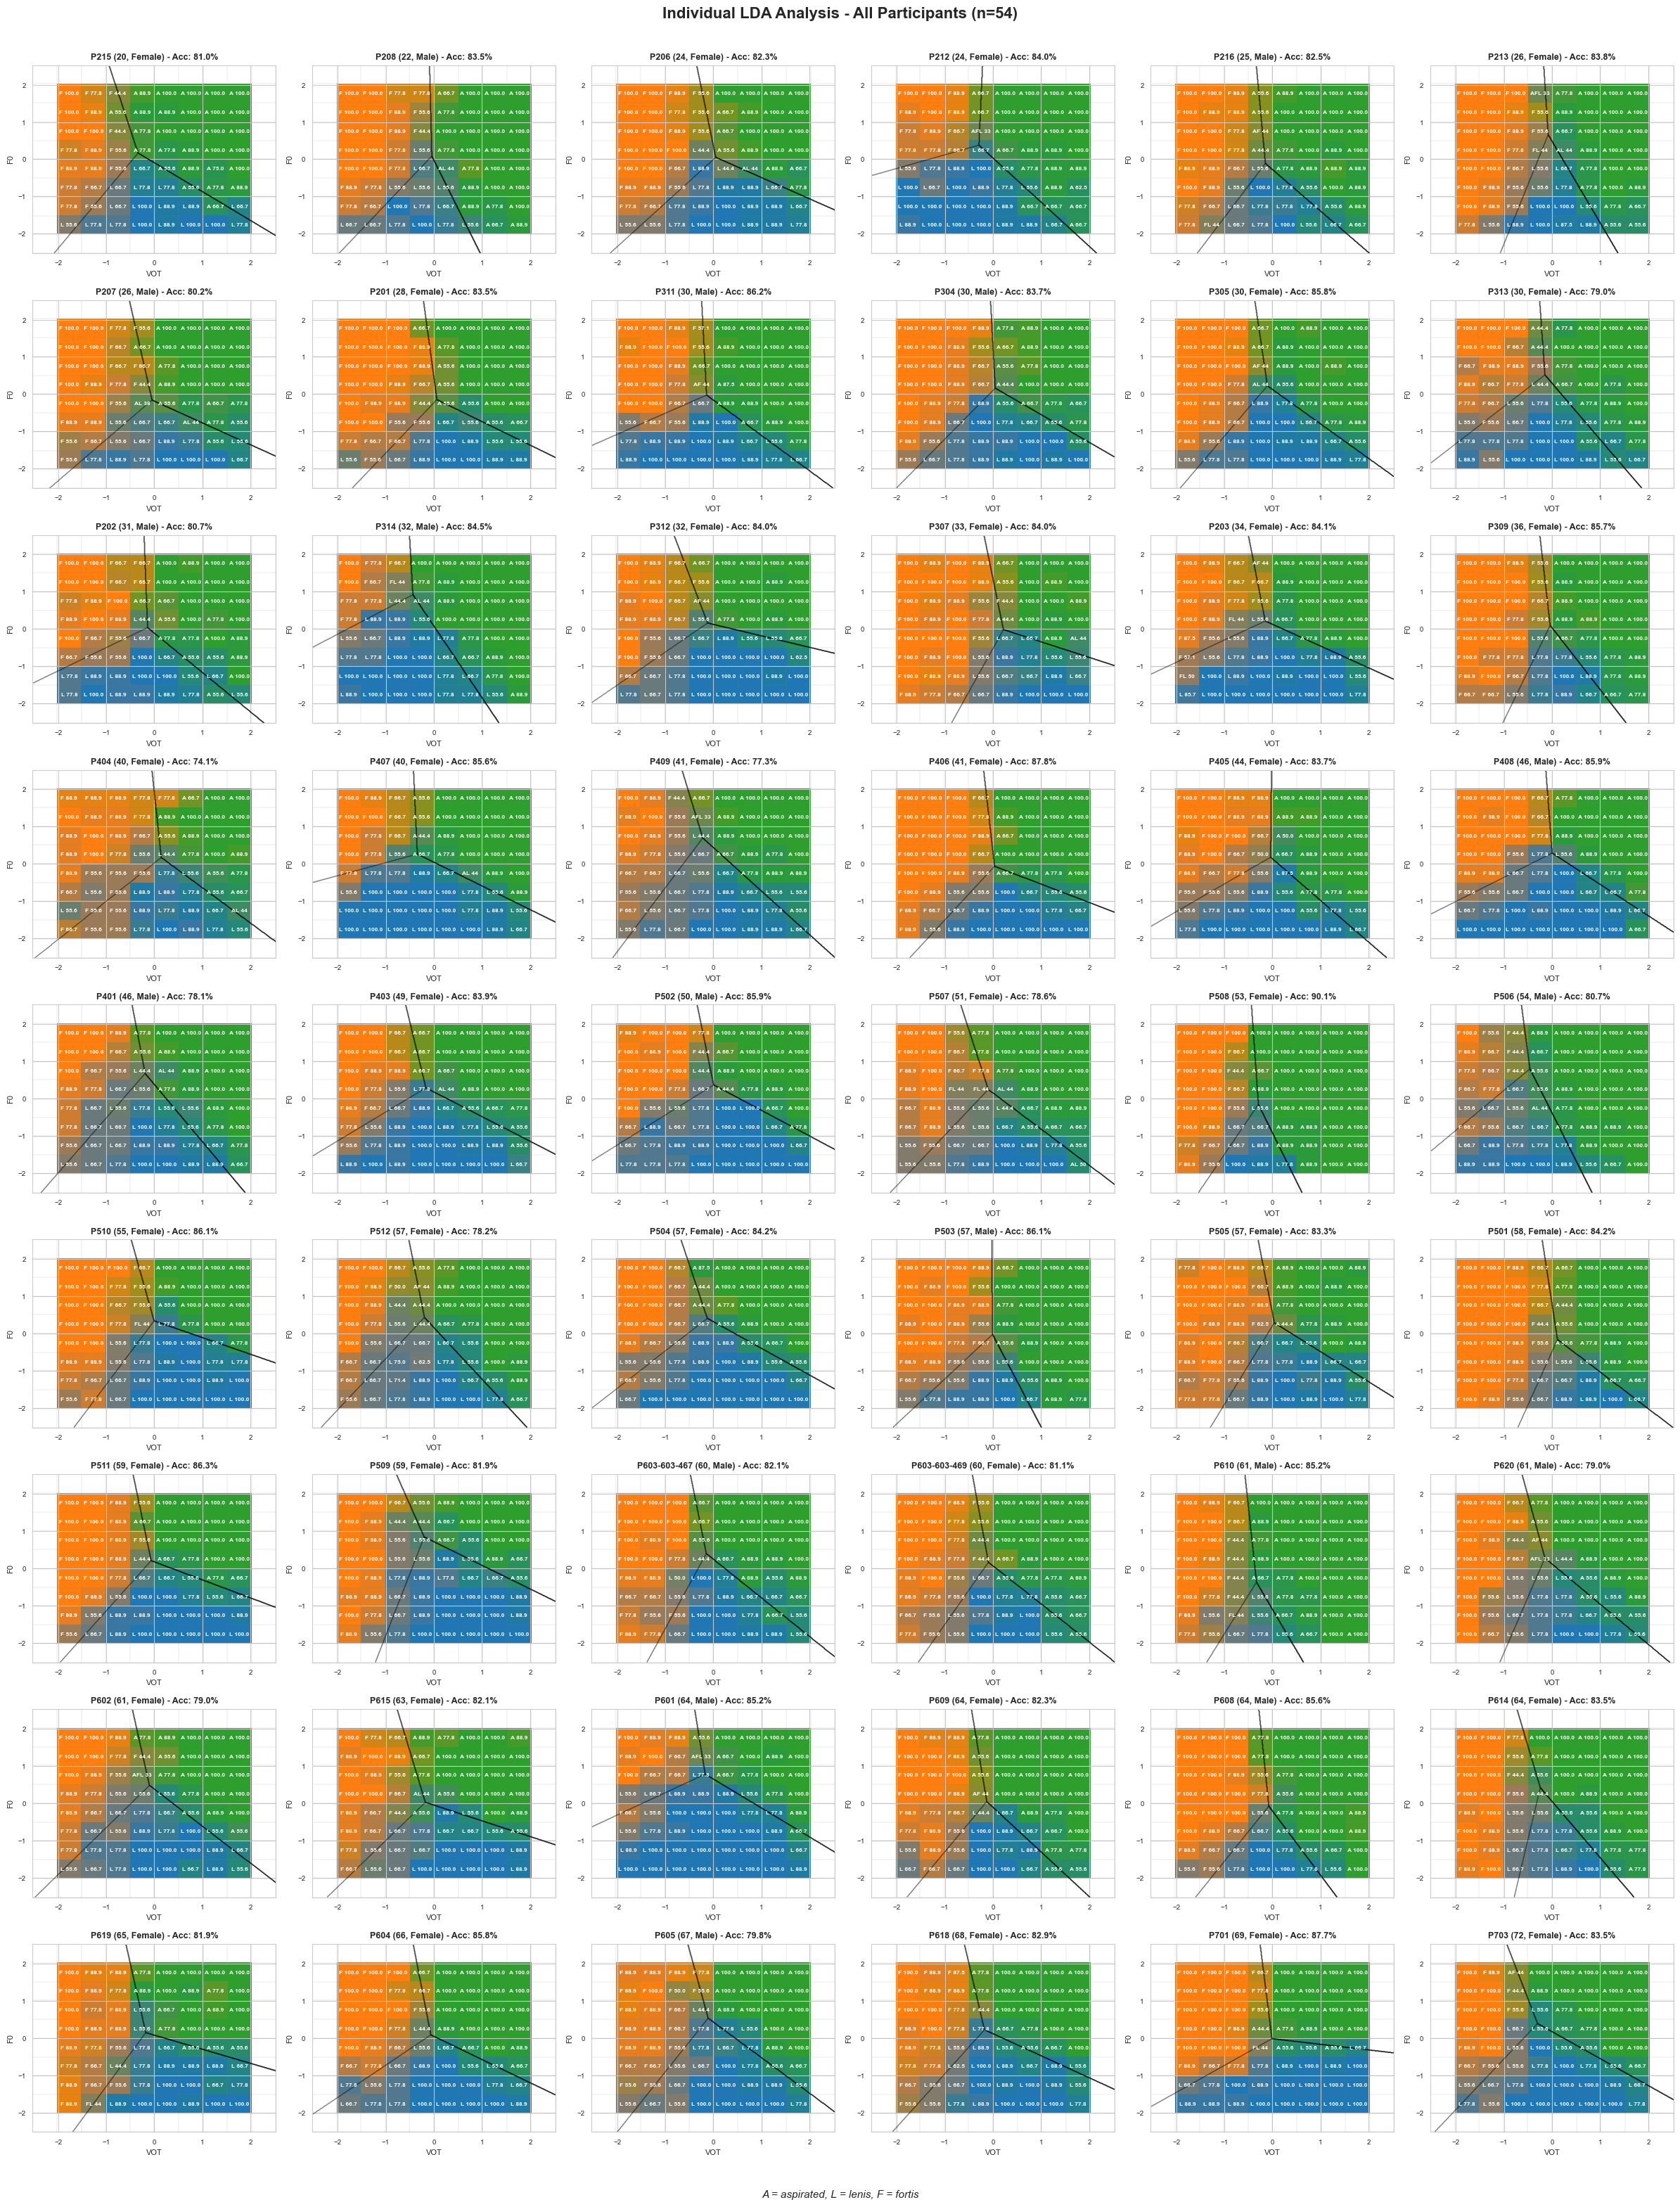


✓ All heatmaps generated using pre-fitted models!


In [9]:
# Create heatmaps for all participants using pre-fitted models
import os

# Use perception_df as data source (already loaded above)
data = perception_df

# Get participant information
participant_info = data[['subject', 'prolific_participant_id', 'age', 'gender']].drop_duplicates().sort_values('age')

# Create output directory
output_dir = './output/individual_lda_heatmaps'
os.makedirs(output_dir, exist_ok=True)

print(f"\nGenerating heatmaps using pre-fitted models...")

# Get participants with models
participants_with_models = [(row['subject'], row['prolific_participant_id']) 
                            for _, row in participant_info.iterrows() 
                            if row['subject'] in lda_models]

n_participants = len(participants_with_models)
print(f"Participants to plot: {n_participants}")

# Calculate grid dimensions
n_cols = 6
n_rows = int(np.ceil(n_participants / n_cols))

# Create figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))

# Handle different axes shapes
if n_participants == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

# Plot each participant
for idx, (participant_id, prolific_id) in enumerate(participants_with_models):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row, col]
    
    participant_data = data[data['subject'] == participant_id].copy()
    lda_model = lda_models[participant_id]
    
    create_participant_lda_heatmap(participant_id, prolific_id, participant_data, lda_model, ax)
    
    if (idx + 1) % 10 == 0:
        print(f"  - Processed {idx + 1}/{n_participants} participants")

# Hide unused subplots
for idx in range(n_participants, n_rows * n_cols):
    row = idx // n_cols
    col = idx % n_cols
    axes[row, col].axis('off')

# Add title and legend
fig.suptitle(f'Individual LDA Analysis - All Participants (n={n_participants})', 
             fontsize=16, fontweight='bold', y=0.995)
fig.text(0.5, 0.005, 'A = aspirated, L = lenis, F = fortis', 
         ha='center', va='bottom', fontsize=11, style='italic')

plt.tight_layout(rect=[0, 0.02, 1, 0.99])

# Save figure
filename = f'{output_dir}/all_participants_lda_heatmaps.png'
plt.savefig(filename, dpi=150, bbox_inches='tight')
print(f"\n✓ Saved: {filename}")

plt.show()
plt.close()

print("\n✓ All heatmaps generated using pre-fitted models!")